# 6. Classification Threshold Optimization

This notebook investigates the effect of changing the classification
threshold for credit default prediction.

The default classification threshold of 0.50 is not necessarily
optimal for credit-risk applications.

The analysis compares the original XGBoost model and the tuned
XGBoost model across different probability thresholds.

The following metrics are evaluated:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- False Positive Rate
- False Negative Rate

The objective is to understand the trade-off between identifying
defaulting customers and incorrectly classifying non-defaulting
customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [5]:
# Load data

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (24000, 39)
X_test: (6000, 39)


In [ ]:
# Load saved tuned model

import joblib

tuned_xgb_model = joblib.load(
    "../models/tuned_xgboost_model.pkl"
)

print("Tuned XGBoost model loaded.")

Tuned XGBoost model loaded.


#### Get tuned probabilities

In [8]:
tuned_proba = tuned_xgb_model.predict_proba(
    X_test
)[:, 1]

print("Tuned probability statistics:")
print(pd.Series(tuned_proba).describe())

Tuned probability statistics:
count    6000.000000
mean        0.415398
std         0.225757
min         0.069196
25%         0.242656
50%         0.364205
75%         0.545162
max         0.946515
dtype: float64


In [9]:
# Load saved original XGBoost model

original_xgb_model = joblib.load("../models/original_xgboost_model.pkl")

print("Original XGBoost model loaded.")

Original XGBoost model loaded.


#### Get original probabilities

In [10]:
original_proba = original_xgb_model.predict_proba(
    X_test
)[:, 1]

print("Original probability statistics:")
print(pd.Series(original_proba).describe())

Original probability statistics:
count    6000.000000
mean        0.220844
std         0.207085
min         0.009549
25%         0.080109
50%         0.140865
75%         0.282982
max         0.935980
dtype: float64


#### Verify ROC-AUC and PR-AUC

In [11]:
print(
    "Original XGBoost ROC-AUC:",
    roc_auc_score(y_test, original_proba)
)

print(
    "Original XGBoost PR-AUC:",
    average_precision_score(y_test, original_proba)
)

print(
    "\nTuned XGBoost ROC-AUC:",
    roc_auc_score(y_test, tuned_proba)
)

print(
    "Tuned XGBoost PR-AUC:",
    average_precision_score(y_test, tuned_proba)
)

Original XGBoost ROC-AUC: 0.7795693679366033
Original XGBoost PR-AUC: 0.5549212711536042

Tuned XGBoost ROC-AUC: 0.7822998640073625
Tuned XGBoost PR-AUC: 0.5621647020425923


#### Create threshold evaluation function

In [12]:
def evaluate_thresholds(
    y_true,
    probabilities,
    model_name
):
    
    thresholds = np.arange(
        0.10,
        0.71,
        0.01
    )

    results = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions
        ).ravel()

        results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Accuracy": accuracy_score(
                y_true,
                predictions
            ),
            "Balanced Accuracy": balanced_accuracy_score(
                y_true,
                predictions
            ),
            "Precision": precision_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "False Positive Rate": fp / (fp + tn),
            "False Negative Rate": fn / (fn + tp),
            "True Positives": tp,
            "False Positives": fp,
            "True Negatives": tn,
            "False Negatives": fn
        })

    return pd.DataFrame(results)

#### Evaluate original XGBoost thresholds

In [13]:
original_threshold_results = evaluate_thresholds(
    y_test,
    original_proba,
    "Original XGBoost"
)

original_threshold_results.head()

,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,False Positive Rate,False Negative Rate,True Positives,False Positives,True Negatives,False Negatives
0,Original XGBoost,0.10,0.508833,0.643939,0.296073,0.886209,0.443857,0.598331,0.113791,1176,2796,1877,151
1,Original XGBoost,0.11,0.541500,0.658166,0.308910,0.867370,0.455571,0.551038,0.132630,1151,2575,2098,176
2,Original XGBoost,0.12,0.572167,0.668141,0.321326,0.840241,0.464874,0.503959,0.159759,1115,2355,2318,212
3,Original XGBoost,0.13,0.601000,0.679637,0.335593,0.820648,0.476378,0.461374,0.179352,1089,2156,2517,238
4,Original XGBoost,0.14,0.628667,0.689035,0.350679,0.797287,0.487109,0.419217,0.202713,1058,1959,2714,269


#### Evaluate tuned XGBoost thresholds

In [14]:
tuned_threshold_results = evaluate_thresholds(
    y_test,
    tuned_proba,
    "Tuned XGBoost"
)

tuned_threshold_results.head()

,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,False Positive Rate,False Negative Rate,True Positives,False Positives,True Negatives,False Negatives
0,Tuned XGBoost,0.10,0.237333,0.509839,0.224614,0.998493,0.366731,0.978814,0.001507,1325,4574,99,2
1,Tuned XGBoost,0.11,0.247333,0.515989,0.226829,0.997739,0.369626,0.965761,0.002261,1324,4513,160,3
2,Tuned XGBoost,0.12,0.260167,0.523688,0.229673,0.996232,0.373288,0.948855,0.003768,1322,4434,239,5
3,Tuned XGBoost,0.13,0.272667,0.530634,0.232329,0.993218,0.376571,0.931949,0.006782,1318,4355,318,9
4,Tuned XGBoost,0.14,0.285833,0.537738,0.235136,0.989450,0.379974,0.913974,0.010550,1313,4271,402,14


#### Combine results

In [15]:
threshold_results = pd.concat(
    [
        original_threshold_results,
        tuned_threshold_results
    ],
    ignore_index=True
)

threshold_results.head()

,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1,False Positive Rate,False Negative Rate,True Positives,False Positives,True Negatives,False Negatives
0,Original XGBoost,0.10,0.508833,0.643939,0.296073,0.886209,0.443857,0.598331,0.113791,1176,2796,1877,151
1,Original XGBoost,0.11,0.541500,0.658166,0.308910,0.867370,0.455571,0.551038,0.132630,1151,2575,2098,176
2,Original XGBoost,0.12,0.572167,0.668141,0.321326,0.840241,0.464874,0.503959,0.159759,1115,2355,2318,212
3,Original XGBoost,0.13,0.601000,0.679637,0.335593,0.820648,0.476378,0.461374,0.179352,1089,2156,2517,238
4,Original XGBoost,0.14,0.628667,0.689035,0.350679,0.797287,0.487109,0.419217,0.202713,1058,1959,2714,269


#### Find best F1 threshold

In [16]:
# For original model

best_original_f1 = (
    original_threshold_results
    .loc[
        original_threshold_results["F1"].idxmax()
    ]
)

print("Best Original XGBoost threshold by F1:")
print(best_original_f1)

Best Original XGBoost threshold by F1:
Model                  Original XGBoost
Threshold                          0.28
Accuracy                       0.783667
Balanced Accuracy              0.711382
Precision                      0.509571
Recall                         0.581763
F1                             0.543279
False Positive Rate            0.158999
False Negative Rate            0.418237
True Positives                      772
False Positives                     743
True Negatives                     3930
False Negatives                     555
Name: 18, dtype: object


In [17]:
# For tunned model 

best_tuned_f1 = (
    tuned_threshold_results
    .loc[
        tuned_threshold_results["F1"].idxmax()
    ]
)

print("\nBest Tuned XGBoost threshold by F1:")
print(best_tuned_f1)


Best Tuned XGBoost threshold by F1:
Model                  Tuned XGBoost
Threshold                       0.56
Accuracy                    0.791833
Balanced Accuracy           0.713118
Precision                   0.527083
Recall                      0.571967
F1                          0.548609
False Positive Rate         0.145731
False Negative Rate         0.428033
True Positives                   759
False Positives                  681
True Negatives                  3992
False Negatives                  568
Name: 46, dtype: object


#### Find best balanced accuracy threshold

In [18]:
best_original_balanced = (
    original_threshold_results
    .loc[
        original_threshold_results[
            "Balanced Accuracy"
        ].idxmax()
    ]
)

best_tuned_balanced = (
    tuned_threshold_results
    .loc[
        tuned_threshold_results[
            "Balanced Accuracy"
        ].idxmax()
    ]
)

print("Original XGBoost:")
print(best_original_balanced)

print("\nTuned XGBoost:")
print(best_tuned_balanced)

Original XGBoost:
Model                  Original XGBoost
Threshold                          0.24
Accuracy                          0.762
Balanced Accuracy              0.711772
Precision                      0.471159
Recall                         0.621703
F1                             0.536062
False Positive Rate             0.19816
False Negative Rate            0.378297
True Positives                      825
False Positives                     926
True Negatives                     3747
False Negatives                     502
Name: 14, dtype: object

Tuned XGBoost:
Model                  Tuned XGBoost
Threshold                       0.56
Accuracy                    0.791833
Balanced Accuracy           0.713118
Precision                   0.527083
Recall                      0.571967
F1                          0.548609
False Positive Rate         0.145731
False Negative Rate         0.428033
True Positives                   759
False Positives                  681
True Negatives 

#### Show useful threshold ranges

In [19]:
display(
    original_threshold_results[
        [
            "Threshold",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1"
        ]
    ].round(4)
)

,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1
0,0.10,0.5088,0.6439,0.2961,0.8862,0.4439
1,0.11,0.5415,0.6582,0.3089,0.8674,0.4556
2,0.12,0.5722,0.6681,0.3213,0.8402,0.4649
3,0.13,0.6010,0.6796,0.3356,0.8206,0.4764
4,0.14,0.6287,0.6890,0.3507,0.7973,0.4871
...,...,...,...,...,...,...
56,0.66,0.8130,0.6104,0.7273,0.2472,0.3690
57,0.67,0.8115,0.6046,0.7311,0.2336,0.3541
58,0.68,0.8115,0.6019,0.7426,0.2261,0.3466
59,0.69,0.8092,0.5961,0.7358,0.2140,0.3316


In [20]:
display(
    tuned_threshold_results[
        [
            "Threshold",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "F1"
        ]
    ].round(4)
)

,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1
0,0.10,0.2373,0.5098,0.2246,0.9985,0.3667
1,0.11,0.2473,0.5160,0.2268,0.9977,0.3696
2,0.12,0.2602,0.5237,0.2297,0.9962,0.3733
3,0.13,0.2727,0.5306,0.2323,0.9932,0.3766
4,0.14,0.2858,0.5377,0.2351,0.9894,0.3800
...,...,...,...,...,...,...
56,0.66,0.8122,0.6876,0.5969,0.4642,0.5223
57,0.67,0.8150,0.6846,0.6108,0.4506,0.5186
58,0.68,0.8158,0.6808,0.6178,0.4386,0.5130
59,0.69,0.8167,0.6767,0.6257,0.4258,0.5067


#### Plot F1 vs threshold

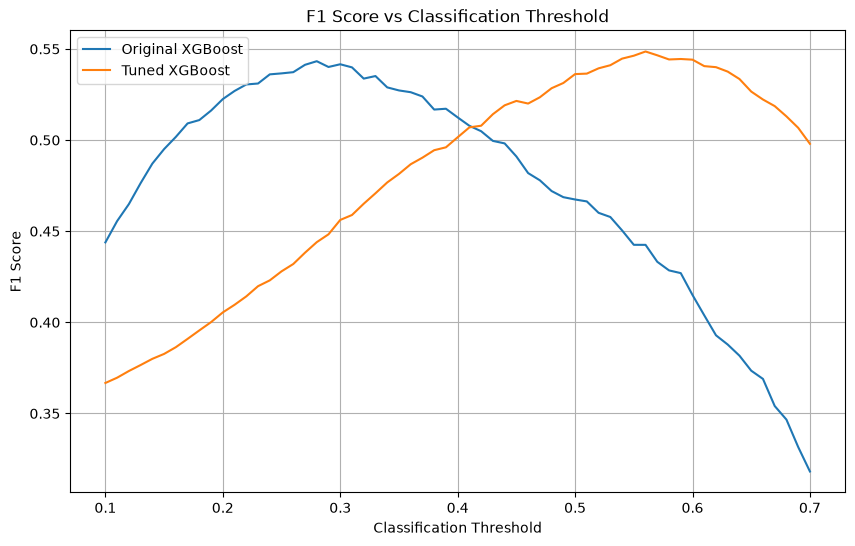

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    original_threshold_results["Threshold"],
    original_threshold_results["F1"],
    label="Original XGBoost"
)

plt.plot(
    tuned_threshold_results["Threshold"],
    tuned_threshold_results["F1"],
    label="Tuned XGBoost"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.grid(True)

plt.show()

#### Plot Recall vs Precision

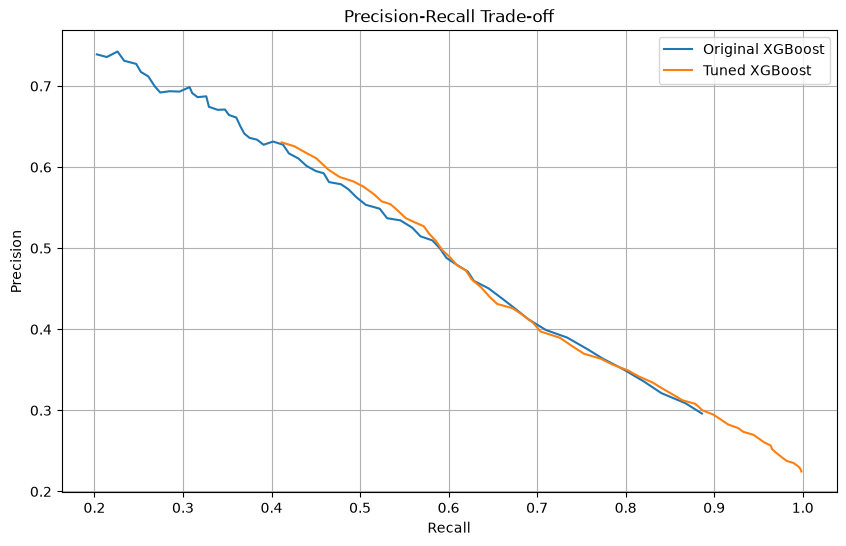

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    original_threshold_results["Recall"],
    original_threshold_results["Precision"],
    label="Original XGBoost"
)

plt.plot(
    tuned_threshold_results["Recall"],
    tuned_threshold_results["Precision"],
    label="Tuned XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.grid(True)

plt.show()

#### Plot Balanced Accuracy

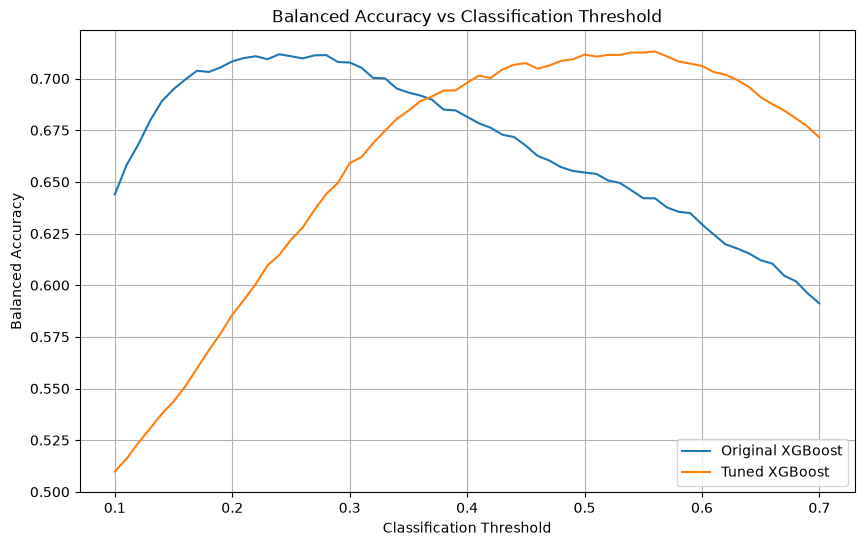

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    original_threshold_results["Threshold"],
    original_threshold_results["Balanced Accuracy"],
    label="Original XGBoost"
)

plt.plot(
    tuned_threshold_results["Threshold"],
    tuned_threshold_results["Balanced Accuracy"],
    label="Tuned XGBoost"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy vs Classification Threshold")
plt.legend()
plt.grid(True)

plt.show()

#### Find a threshold with high recall

In [24]:
original_recall_50 = original_threshold_results[
    original_threshold_results["Recall"] >= 0.50
]

tuned_recall_50 = tuned_threshold_results[
    tuned_threshold_results["Recall"] >= 0.50
]

print("Original XGBoost thresholds with recall >= 50%:")
display(
    original_recall_50[
        [
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Balanced Accuracy"
        ]
    ]
)

print("\nTuned XGBoost thresholds with recall >= 50%:")
display(
    tuned_recall_50[
        [
            "Threshold",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Balanced Accuracy"
        ]
    ]
)

Original XGBoost thresholds with recall >= 50%:


,Threshold,Accuracy,Precision,Recall,F1,Balanced Accuracy
0,0.10,0.508833,0.296073,0.886209,0.443857,0.643939
1,0.11,0.541500,0.308910,0.867370,0.455571,0.658166
2,0.12,0.572167,0.321326,0.840241,0.464874,0.668141
3,0.13,0.601000,0.335593,0.820648,0.476378,0.679637
4,0.14,0.628667,0.350679,0.797287,0.487109,0.689035
5,0.15,0.650833,0.363926,0.773926,0.495059,0.694902
6,0.16,0.667333,0.375140,0.757347,0.501747,0.699560
7,0.17,0.687000,0.389756,0.733986,0.509148,0.703822
8,0.18,0.699500,0.399153,0.709872,0.510985,0.703213
9,0.19,0.713833,0.412241,0.690279,0.516202,0.705400



Tuned XGBoost thresholds with recall >= 50%:


,Threshold,Accuracy,Precision,Recall,F1,Balanced Accuracy
0,0.10,0.237333,0.224614,0.998493,0.366731,0.509839
1,0.11,0.247333,0.226829,0.997739,0.369626,0.515989
2,0.12,0.260167,0.229673,0.996232,0.373288,0.523688
3,0.13,0.272667,0.232329,0.993218,0.376571,0.530634
4,0.14,0.285833,0.235136,0.989450,0.379974,0.537738
5,0.15,0.299333,0.237644,0.981914,0.382673,0.543707
6,0.16,0.312833,0.240727,0.978146,0.386367,0.551025
7,0.17,0.329000,0.244558,0.973625,0.390923,0.559785
8,0.18,0.345000,0.248502,0.969103,0.395571,0.568438
9,0.19,0.359833,0.252364,0.965335,0.400125,0.576612


In [25]:
# Save threshold results

threshold_results.to_csv(
    "../reports/threshold_optimization_results.csv",
    index=False
)

print("Threshold analysis results saved.")

Threshold analysis results saved.
